# Accessing the ESA Mediterranean Sea Datacube

[Explore Data](https://sunnydean.github.io/ocean_cubes_vis/?cube=https%3A%2F%2Fs3.waw4-1.cloudferro.com%2FEarthCODE%2FOSCAssets%2Fmed_cubes%2Focean-med-daily-surface-cube.zarr&variable=sos) · [Explore Data](https://sunnydean.github.io/ocean_cubes_vis/?cube=https%3A%2F%2Fs3.waw4-1.cloudferro.com%2FEarthCODE%2FOSCAssets%2Fmed_cubes%2Focean-med-monthly-cube.zarr&variable=DIATO) · [Explore Data](https://sunnydean.github.io/ocean_cubes_vis/?cube=https%3A%2F%2Fs3.waw4-1.cloudferro.com%2FEarthCODE%2FOSCAssets%2Fmed_cubes%2Focean-med-biophysics.zarr&variable=to) · [Explore Data](https://sunnydean.github.io/ocean_cubes_vis/?cube=https%3A%2F%2Fs3.waw4-1.cloudferro.com%2FEarthCODE%2FOSCAssets%2Fmed_cubes%2Fhourly_cube.zarr&variable=ut_woc)

This notebook opens the four online stores of the ESA Mediterranean Sea Datacube and plots selected variables. Group `0` provides full resolution; groups `1` and `2` provide coarser spatial summaries.

The example uses a small Alboran Sea ROI. Change `ROI_CENTER_LON_LAT` or `ROI_HALF_WIDTH_CELLS` to explore another area. Reads happen at the Zarr chunk level, so a small selection may still read a larger stored chunk.

## Setup

Set `CUBE_LEVEL` to `"0"` for full resolution, `"1"` for 1/6°, or `"2"` for 1/3°. Each cube is opened with `xr.open_zarr` when it is needed below. The examples use June 2019.

In [31]:
import numpy as np
import xarray as xr
from dask.diagnostics import ProgressBar
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt

CUBE_LEVEL = "0"
ROI_CENTER_LON_LAT = (-2.5, 36.0)
ROI_HALF_WIDTH_CELLS = 100
VELOCITY_VECTOR_STRIDE = 6
DAILY_TIME_TARGET = "2019-06-01"
MONTHLY_TIME_TARGET = "2019-06-01"
HOURLY_TIME_TARGET = "2019-06-01T12:00:00"
BIOPHYSICS_DEPTH_TARGET_M = 19.0

## Open the Daily Surface Cube

Start with the daily surface cube for the region map, salinity, density, and sea-level examples.

In [32]:
daily_surface_cube = xr.open_zarr(
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/med_cubes/ocean-med-daily-surface-cube.zarr",
    group=CUBE_LEVEL, chunks={}, consolidated=True, decode_coords="all",
)
daily_surface_cube

<xarray.Dataset> Size: 157GB
Dimensions:                          (time: 2557, lat: 378, lon: 1012)
Coordinates:
  * time                             (time) datetime64[ns] 20kB 2016-01-01 .....
  * lat                              (lat) float32 2kB 30.27 30.31 ... 45.98
  * lon                              (lon) float32 4kB -6.062 -6.021 ... 36.06
    spatial_ref                      int64 8B ...
Data variables: (12/22)
    adt_4dvarnet                     (time, lat, lon) float64 8GB dask.array<chunksize=(1, 189, 506), meta=np.ndarray>
    adt_4dvarnet_ssh                 (time, lat, lon) float64 8GB dask.array<chunksize=(1, 189, 506), meta=np.ndarray>
    category                         (time, lat, lon) float32 4GB dask.array<chunksize=(1, 189, 506), meta=np.ndarray>
    dos                              (time, lat, lon) float64 8GB dask.array<chunksize=(1, 189, 506), meta=np.ndarray>
    dos_error                        (time, lat, lon) float64 8GB dask.array<chunksize=(1, 189, 506), meta=np.ndarray>
    fsle                             (time, lat, lon) float64 8GB dask.array<chunksize=(1, 189, 506), meta=np.ndarray>
    ...                               ...
    ugosa_4dvarnet_ssh               (time, lat, lon) float64 8GB dask.array<chunksize=(1, 189, 506), meta=np.ndarray>
    vgos_4dvarnet                    (time, lat, lon) float64 8GB dask.array<chunksize=(1, 189, 506), meta=np.ndarray>
    vgos_4dvarnet_ssh                (time, lat, lon) float64 8GB dask.array<chunksize=(1, 189, 506), meta=np.ndarray>
    vgosa_4dvarnet                   (time, lat, lon) float64 8GB dask.array<chunksize=(1, 189, 506), meta=np.ndarray>
    vgosa_4dvarnet_ssh               (time, lat, lon) float64 8GB dask.array<chunksize=(1, 189, 506), meta=np.ndarray>
    water_mask                       (lat, lon) uint8 383kB dask.array<chunksize=(189, 506), meta=np.ndarray>
Attributes: (12/15)
    title:                   Mediterranean grid
    grid_resolution:         1/24 degree
    geospatial_lat_min:      30.27083396911621
    geospatial_lat_max:      45.97916793823242
    geospatial_lon_min:      -6.062498092651367
    geospatial_lon_max:      36.0625
    ...                      ...
    spatial:dimensions:      ['lat', 'lon']
    spatial:bbox:            [-6.083331425041402, 30.250000634939664, 36.0833...
    spatial:transform_type:  affine
    spatial:shape:           [378, 1012]
    spatial:registration:    pixel
    zarr_conventions:        [{'uuid': 'f17cb550-5864-4468-aeb7-f3180cfb622f'...

## Select A Small Region Of Interest

Select a region from the daily surface cube. The code snaps the requested point to the nearest grid cell and clips the slices at the cube edges. All four stores share the same horizontal grid, so the later examples reuse these slices.

In [33]:
x_index = int(np.abs(daily_surface_cube.lon.values - ROI_CENTER_LON_LAT[0]).argmin())
y_index = int(np.abs(daily_surface_cube.lat.values - ROI_CENTER_LON_LAT[1]).argmin())
x_slice = slice(max(0, x_index - ROI_HALF_WIDTH_CELLS),
                min(daily_surface_cube.sizes["lon"], x_index + ROI_HALF_WIDTH_CELLS + 1))
y_slice = slice(max(0, y_index - ROI_HALF_WIDTH_CELLS),
                min(daily_surface_cube.sizes["lat"], y_index + ROI_HALF_WIDTH_CELLS + 1))
surface_region = daily_surface_cube.isel(lon=x_slice, lat=y_slice)
surface_region

<xarray.Dataset> Size: 15GB
Dimensions:                          (time: 2557, lat: 201, lon: 186)
Coordinates:
  * time                             (time) datetime64[ns] 20kB 2016-01-01 .....
  * lat                              (lat) float32 804B 31.81 31.85 ... 40.15
  * lon                              (lon) float32 744B -6.062 -6.021 ... 1.646
    spatial_ref                      int64 8B ...
Data variables: (12/22)
    adt_4dvarnet                     (time, lat, lon) float64 765MB dask.array<chunksize=(1, 152, 186), meta=np.ndarray>
    adt_4dvarnet_ssh                 (time, lat, lon) float64 765MB dask.array<chunksize=(1, 152, 186), meta=np.ndarray>
    category                         (time, lat, lon) float32 382MB dask.array<chunksize=(1, 152, 186), meta=np.ndarray>
    dos                              (time, lat, lon) float64 765MB dask.array<chunksize=(1, 152, 186), meta=np.ndarray>
    dos_error                        (time, lat, lon) float64 765MB dask.array<chunksize=(1, 152, 186), meta=np.ndarray>
    fsle                             (time, lat, lon) float64 765MB dask.array<chunksize=(1, 152, 186), meta=np.ndarray>
    ...                               ...
    ugosa_4dvarnet_ssh               (time, lat, lon) float64 765MB dask.array<chunksize=(1, 152, 186), meta=np.ndarray>
    vgos_4dvarnet                    (time, lat, lon) float64 765MB dask.array<chunksize=(1, 152, 186), meta=np.ndarray>
    vgos_4dvarnet_ssh                (time, lat, lon) float64 765MB dask.array<chunksize=(1, 152, 186), meta=np.ndarray>
    vgosa_4dvarnet                   (time, lat, lon) float64 765MB dask.array<chunksize=(1, 152, 186), meta=np.ndarray>
    vgosa_4dvarnet_ssh               (time, lat, lon) float64 765MB dask.array<chunksize=(1, 152, 186), meta=np.ndarray>
    water_mask                       (lat, lon) uint8 37kB dask.array<chunksize=(152, 186), meta=np.ndarray>
Attributes: (12/15)
    title:                   Mediterranean grid
    grid_resolution:         1/24 degree
    geospatial_lat_min:      30.27083396911621
    geospatial_lat_max:      45.97916793823242
    geospatial_lon_min:      -6.062498092651367
    geospatial_lon_max:      36.0625
    ...                      ...
    spatial:dimensions:      ['lat', 'lon']
    spatial:bbox:            [-6.083331425041402, 30.250000634939664, 36.0833...
    spatial:transform_type:  affine
    spatial:shape:           [378, 1012]
    spatial:registration:    pixel
    zarr_conventions:        [{'uuid': 'f17cb550-5864-4468-aeb7-f3180cfb622f'...

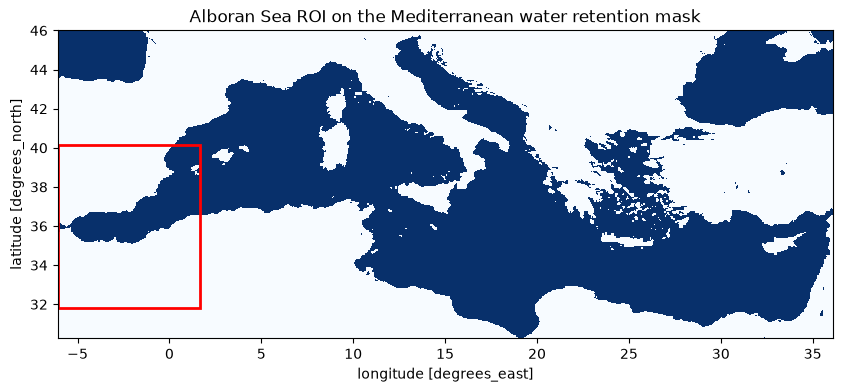

In [34]:
region = surface_region
fig, ax = plt.subplots(figsize=(10, 4))
daily_surface_cube.water_mask.plot(ax=ax, cmap="Blues", add_colorbar=False)
ax.add_patch(Rectangle(
    (float(region.lon.min()), float(region.lat.min())),
    float(region.lon.max() - region.lon.min()),
    float(region.lat.max() - region.lat.min()),
    fill=False, edgecolor="red", linewidth=2,
))
ax.set_title("Alboran Sea ROI on the Mediterranean water retention mask")
plt.show()

## Plot 1: Sea-Surface Salinity And Density

The daily surface store combines 4DMED sea-surface salinity (`sos`) and density (`dos`) with their error fields. Both maps use the same region and day. Missing cells remain masked; consult the variable attributes for the source units and error definitions.

[########################################] | 100% Completed | 202.01 ms


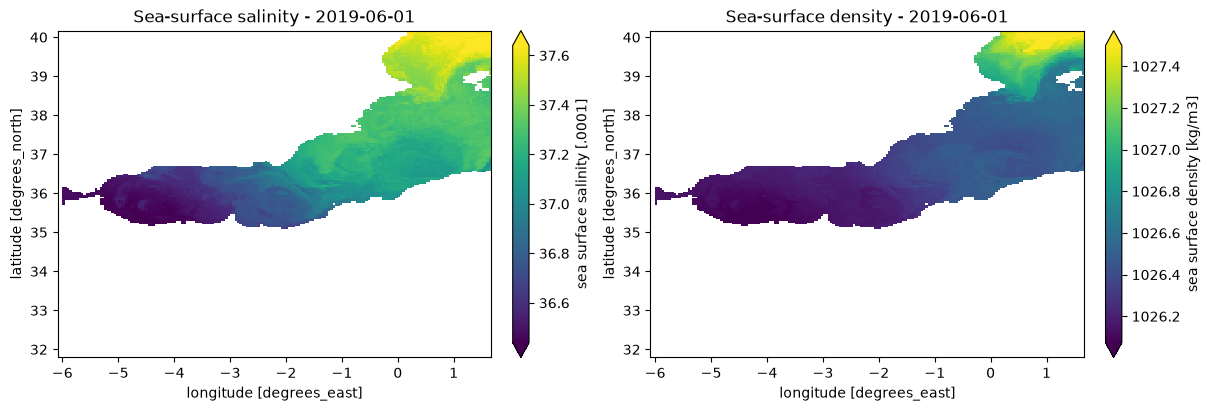

In [35]:
with ProgressBar():
    surface = surface_region[["sos", "dos"]].sel(time=DAILY_TIME_TARGET).compute()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for ax, name, title in zip(axes, ["sos", "dos"], ["Sea-surface salinity", "Sea-surface density"]):
    surface[name].plot(ax=ax, cmap="viridis", robust=True)
    ax.set_title(f"{title} - {DAILY_TIME_TARGET}")
plt.show()

## Plot 2: Sea Level And Geostrophic Currents

The 1/8° and 1/20° 4DVarNet reconstructions are retained as separate variables. This example plots absolute dynamic topography from the 1/8° product with its own eastward and northward geostrophic currents. Use the `_4dvarnet_ssh` variables to explore the other reconstruction.

[########################################] | 100% Completed | 201.62 ms


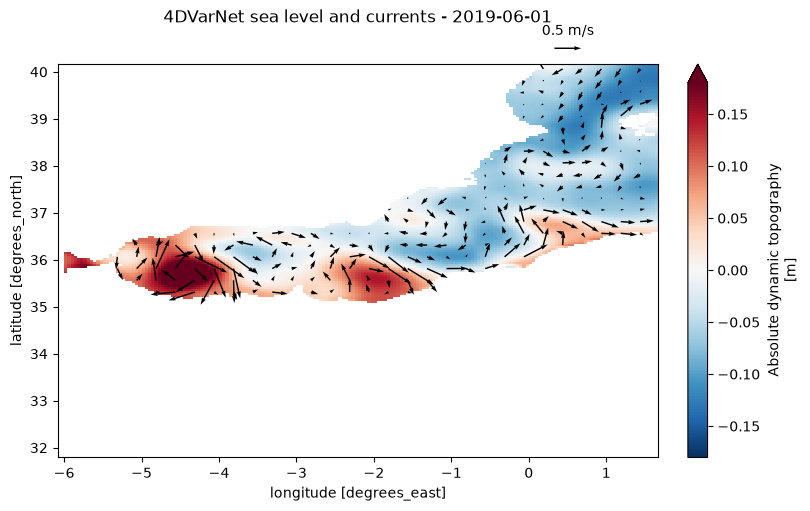

In [36]:
with ProgressBar():
    sea_level = surface_region[[
        "adt_4dvarnet", "ugos_4dvarnet", "vgos_4dvarnet"
    ]].sel(time=DAILY_TIME_TARGET).compute()

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
sea_level.adt_4dvarnet.plot(ax=ax, cmap="RdBu_r", robust=True)
vectors = sea_level.isel(lat=slice(None, None, VELOCITY_VECTOR_STRIDE),
                         lon=slice(None, None, VELOCITY_VECTOR_STRIDE))
q = ax.quiver(vectors.lon, vectors.lat, vectors.ugos_4dvarnet, vectors.vgos_4dvarnet)
ax.quiverkey(q, 0.85, 1.04, 0.5, "0.5 m/s")
ax.set_title(f"4DVarNet sea level and currents - {DAILY_TIME_TARGET}", pad=30)
plt.show()

## Plot 3: Phytoplankton And Carbonate Chemistry

Monthly 4DMED diatom chlorophyll-a (`DIATO`) and OceanSODA total-scale pH (`ph_total`) can be displayed on the same grid. Their source resolutions differ: matching pixel locations does not imply matching effective resolution or observation methods.

[########################################] | 100% Completed | 403.09 ms


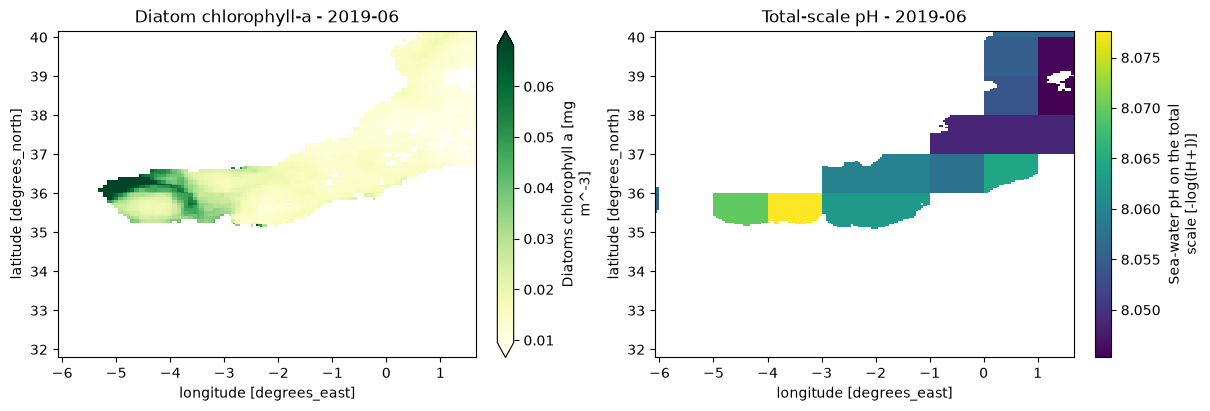

In [37]:
monthly_cube = xr.open_zarr(
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/med_cubes/ocean-med-monthly-cube.zarr",
    group=CUBE_LEVEL, chunks={}, consolidated=True, decode_coords="all",
)

with ProgressBar():
    monthly = (monthly_cube[["DIATO", "ph_total"]]
               .isel(lon=x_slice, lat=y_slice)
               .sel(time=MONTHLY_TIME_TARGET).compute())

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
monthly.DIATO.plot(ax=axes[0], cmap="YlGn", robust=True)
monthly.ph_total.plot(ax=axes[1], cmap="viridis", robust=True)
axes[0].set_title(f"Diatom chlorophyll-a - {MONTHLY_TIME_TARGET[:7]}")
axes[1].set_title(f"Total-scale pH - {MONTHLY_TIME_TARGET[:7]}")
plt.show()

## Plot 4: Primary Production And Temperature At A Selected Depth

Select 4DMED primary production (`PP`) and sea-water temperature (`to`) at the same timestamp and depth. Both have data at 19 m, one of the 18 biophysics levels. `PP` is a volumetric rate; monthly BICEP `pp` is a different product.

[########################################] | 100% Completed | 1.21 ss


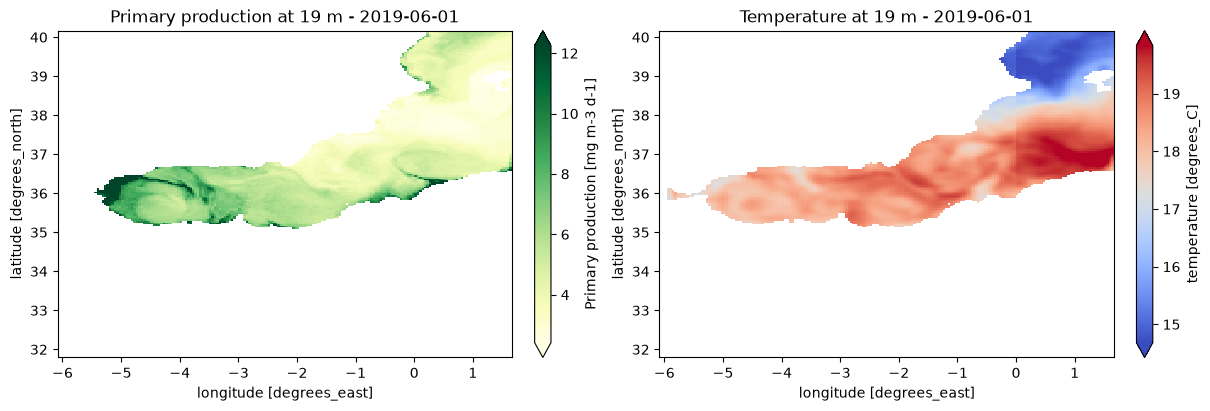

In [38]:
biophysics_cube = xr.open_zarr(
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/med_cubes/ocean-med-biophysics.zarr",
    group=CUBE_LEVEL, chunks={}, consolidated=True, decode_coords="all",
)

with ProgressBar():
    biophysics = (biophysics_cube[["PP", "to"]].isel(lon=x_slice, lat=y_slice)
                  .sel(time=DAILY_TIME_TARGET)
                  .sel(depth=BIOPHYSICS_DEPTH_TARGET_M).compute())
selected_depth = float(biophysics.depth)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
biophysics.PP.plot(ax=axes[0], cmap="YlGn", robust=True, cbar_kwargs={"label": "Primary production [mg m-3 d-1]"})
biophysics["to"].plot(ax=axes[1], cmap="coolwarm", robust=True)
axes[0].set_title(f"Primary production at {selected_depth:g} m - {DAILY_TIME_TARGET}")
axes[1].set_title(f"Temperature at {selected_depth:g} m - {DAILY_TIME_TARGET}")
plt.show()

## Plot 5: Hourly Total Currents At 15 m

The WOC store retains hourly current components at 15 m. Compute speed from the matching total-current components `ut_woc` and `vt_woc`, then overlay arrows. This is one hourly snapshot; it is not a daily or monthly mean.

[########################################] | 100% Completed | 201.39 ms


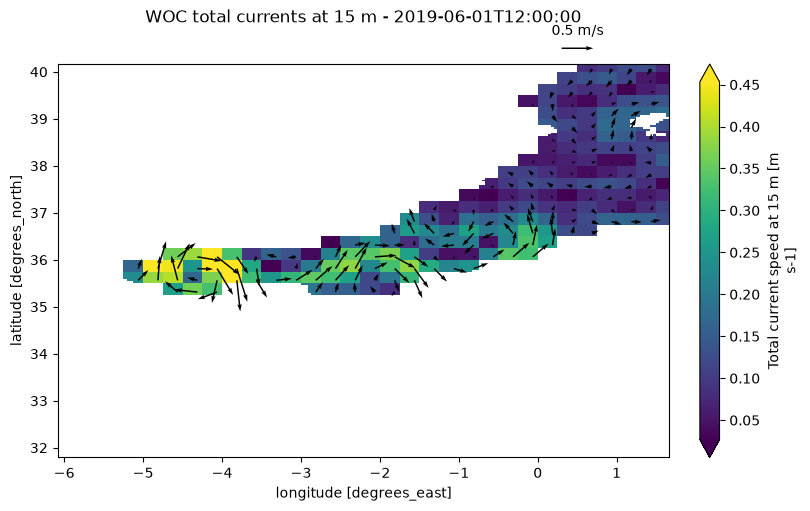

In [39]:
hourly_cube = xr.open_zarr(
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/med_cubes/hourly_cube.zarr",
    group=CUBE_LEVEL, chunks={}, consolidated=True, decode_coords="all",
)

with ProgressBar():
    hourly = (hourly_cube[["ut_woc", "vt_woc"]].isel(lon=x_slice, lat=y_slice)
              .sel(time=HOURLY_TIME_TARGET, depth=15.0).compute())

speed = np.hypot(hourly.ut_woc, hourly.vt_woc).rename("current_speed")
speed.attrs.update(long_name="Total current speed at 15 m", units="m s-1")
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
speed.plot(ax=ax, cmap="viridis", robust=True)
vectors = hourly.isel(lat=slice(None, None, VELOCITY_VECTOR_STRIDE),
                      lon=slice(None, None, VELOCITY_VECTOR_STRIDE))
q = ax.quiver(vectors.lon, vectors.lat, vectors.ut_woc, vectors.vt_woc)
ax.quiverkey(q, 0.85, 1.04, 0.5, "0.5 m/s")
ax.set_title(f"WOC total currents at 15 m - {HOURLY_TIME_TARGET}", pad=30)
plt.show()

## Inspect Variable Metadata

Check the units, provenance, and processing metadata before combining products. The [overview](0_intro.ipynb) explains source naming, coverage gaps, and aggregation. Use [Time Series at Every Depth](3_large_area_processing.ipynb) to explore sea-water temperature through time and depth at one location.

In [40]:
biophysics_cube["PP"].attrs

{'processing_steps': {'regrid_func': 'regrid_kdtree_pyresample',
  'roi_m': 4000,
  'epsilon': 0},
 'standard_name': 'net_primary_production_of_biomass_expressed_as_carbon_per_unit_volume_in_sea_water',
 'long_name': 'Primary Production field estimated from chlorophyll and temperature 3D fields [spatial resolution = 1/24 deg]',
 'description': 'Primary Production field estimated from chlorophyll and temperature 3D fields [spatial resolution = 1/24 deg]',
 'units': 'mg m-3 d-1',
 'source': 'https://esa-earthcode.github.io/open-science-catalog-metadata/products/4dmed-3d-prim-prod-150/collection',
 'reference': 'https://4dmed.artov.ismar.cnr.it/thredds/catalog/4dmed/catalog_PP.html',
 'original_spatial_resolution': [0.04166666478007059, 0.0416666683530934],
 'original_temporal_resolution': '1 days 00:00:00',
 'file_type': 'area',
 'is_mask': False,
 'data_meaning': 'continuous',
 'valid_range': [3.0095383730446977e-25, 923.970458984375],
 'visualization_range': [4.001231412887574, 14.3165

## Close The Datasets

In [41]:
daily_surface_cube.close()
monthly_cube.close()
biophysics_cube.close()
hourly_cube.close()